# 📊 Notebook 01 – Exploración y Limpieza del Dataset
**Smart Diet Planner | CC3045 – Inteligencia Artificial**

En este notebook exploramos los archivos descargados del USDA FoodData Central (SR Legacy),
los combina en un solo dataset limpio y lo guarda en `data/processed/foods_clean.csv`.

**Archivos de entrada:**
- `data/raw/food.csv` → nombres de alimentos
- `data/raw/nutrient.csv` → diccionario de nutrientes
- `data/raw/food_nutrient.csv` → valores nutricionales por alimento

## 1. Imports y configuración

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# Rutas
RAW = '../data/raw/'
PROCESSED = '../data/processed/'
os.makedirs(PROCESSED, exist_ok=True)

print('✅ Imports listos')
print(f'📁 raw:       {os.path.abspath(RAW)}')
print(f'📁 processed: {os.path.abspath(PROCESSED)}')

✅ Imports listos
📁 raw:       /Users/jorgelopez/Downloads/smart-diet-planner/data/raw
📁 processed: /Users/jorgelopez/Downloads/smart-diet-planner/data/processed


## 2. Cargar los 3 archivos base

In [2]:
# Nombres de alimentos
food = pd.read_csv(RAW + 'food.csv')
print(f'food.csv         → {food.shape[0]:,} filas, {food.shape[1]} columnas')
food.head(3)

food.csv         → 7,793 filas, 5 columnas


,fdc_id,data_type,description,food_category_id,publication_date
0,167512,sr_legacy_food,"Pillsbury Golden Layer Buttermilk Biscuits, Ar...",18,2019-04-01
1,167513,sr_legacy_food,"Pillsbury, Cinnamon Rolls with Icing, refriger...",18,2019-04-01
2,167514,sr_legacy_food,"Kraft Foods, Shake N Bake Original Recipe, Coa...",18,2019-04-01


In [3]:
# Diccionario de nutrientes
nutrient = pd.read_csv(RAW + 'nutrient.csv')
print(f'nutrient.csv     → {nutrient.shape[0]:,} filas, {nutrient.shape[1]} columnas')
nutrient.head(10)

nutrient.csv     → 474 filas, 5 columnas


,id,name,unit_name,nutrient_nbr,rank
0,2047,Energy (Atwater General Factors),KCAL,957.0,280.0
1,2048,Energy (Atwater Specific Factors),KCAL,958.0,290.0
2,1001,Solids,G,201.0,200.0
3,1002,Nitrogen,G,202.0,500.0
4,1003,Protein,G,203.0,600.0
5,1004,Total lipid (fat),G,204.0,800.0
6,1005,"Carbohydrate, by difference",G,205.0,1110.0
7,1006,"Fiber, crude (DO NOT USE - Archived)",G,206.0,999999.0
8,1007,Ash,G,207.0,1000.0
9,1008,Energy,KCAL,208.0,300.0


In [4]:
# Valores nutricionales (archivo más grande)
food_nutrient = pd.read_csv(RAW + 'food_nutrient.csv')
print(f'food_nutrient.csv → {food_nutrient.shape[0]:,} filas, {food_nutrient.shape[1]} columnas')
food_nutrient.head(3)

food_nutrient.csv → 644,125 filas, 11 columnas


,id,fdc_id,nutrient_id,amount,data_points,derivation_id,min,max,median,footnote,min_year_acquired
0,1283674,167512,1003,5.88,1,46.0,NaN,NaN,NaN,NaN,NaN
1,1283675,167512,1007,3.50,1,46.0,NaN,NaN,NaN,NaN,NaN
2,1283676,167512,1062,1286.00,0,49.0,NaN,NaN,NaN,NaN,NaN


## 3. Identificar los nutrientes que nos interesan

In [5]:
# Ver todos los nutrientes disponibles
print('Nutrientes disponibles en el dataset:')
print(nutrient[['id', 'name', 'unit_name']].to_string())

Nutrientes disponibles en el dataset:
       id                                                                  name unit_name
0    2047                                      Energy (Atwater General Factors)      KCAL
1    2048                                     Energy (Atwater Specific Factors)      KCAL
2    1001                                                                Solids         G
3    1002                                                              Nitrogen         G
4    1003                                                               Protein         G
5    1004                                                     Total lipid (fat)         G
6    1005                                           Carbohydrate, by difference         G
7    1006                                  Fiber, crude (DO NOT USE - Archived)         G
8    1007                                                                   Ash         G
9    1008                                                     

In [6]:
# Los nutrientes que necesita nuestro proyecto
NUTRIENTES_OBJETIVO = {
    1008: 'calories',    # Energía (kcal)
    1003: 'protein',     # Proteína (g)
    1005: 'carbs',       # Carbohidratos (g)
    1004: 'fat',         # Grasa total (g)
    1079: 'fiber',       # Fibra (g)
    2000: 'sugar',       # Azúcares (g)
}

# Verificar cuáles existen en el dataset
encontrados = nutrient[nutrient['id'].isin(NUTRIENTES_OBJETIVO.keys())][['id', 'name', 'unit_name']]
print('Nutrientes encontrados en el dataset:')
print(encontrados)

Nutrientes encontrados en el dataset:
       id                         name unit_name
4    1003                      Protein         G
5    1004            Total lipid (fat)         G
6    1005  Carbohydrate, by difference         G
9    1008                       Energy      KCAL
80   1079         Fiber, total dietary         G
415  2000                Sugars, Total         G


## 4. Filtrar y pivotar food_nutrient

In [7]:
# Quedarse solo con los nutrientes de interés
fn_filtrado = food_nutrient[food_nutrient['nutrient_id'].isin(NUTRIENTES_OBJETIVO.keys())].copy()
print(f'Filas después del filtro: {fn_filtrado.shape[0]:,}')

# Renombrar nutrient_id con nombre legible
fn_filtrado['nutrient_name'] = fn_filtrado['nutrient_id'].map(NUTRIENTES_OBJETIVO)

fn_filtrado[['fdc_id', 'nutrient_id', 'nutrient_name', 'amount']].head(10)

Filas después del filtro: 44,410


,fdc_id,nutrient_id,nutrient_name,amount
0,167512,1003,protein,5.88
3,167512,1079,fiber,1.20
9,167512,1004,fat,13.24
10,167512,1005,carbs,41.18
11,167512,1008,calories,307.00
13,167512,2000,sugar,5.88
14,167513,1003,protein,4.34
17,167513,1079,fiber,1.40
26,167513,1004,fat,11.27
27,167513,1005,carbs,53.42


In [8]:
# Pivotar: cada fila = un alimento, cada columna = un nutriente
pivote = fn_filtrado.pivot_table(
    index='fdc_id',
    columns='nutrient_name',
    values='amount',
    aggfunc='first'
).reset_index()

print(f'Dataset pivoteado: {pivote.shape[0]:,} alimentos x {pivote.shape[1]} columnas')
pivote.head()

Dataset pivoteado: 7,793 alimentos x 7 columnas


nutrient_name,fdc_id,calories,carbs,fat,fiber,protein,sugar
0,167512,307.0,41.18,13.24,1.2,5.88,5.88
1,167513,330.0,53.42,11.27,1.4,4.34,21.34
2,167514,377.0,79.80,3.70,NaN,6.10,NaN
3,167515,232.0,46.00,1.80,NaN,8.00,NaN
4,167516,273.0,41.05,9.22,2.2,6.58,4.30


## 5. Unir con nombres de alimentos

In [9]:
# Columnas útiles de food.csv
print('Columnas en food.csv:', food.columns.tolist())
food_base = food[['fdc_id', 'description']].copy()
food_base.head()

Columnas en food.csv: ['fdc_id', 'data_type', 'description', 'food_category_id', 'publication_date']


,fdc_id,description
0,167512,"Pillsbury Golden Layer Buttermilk Biscuits, Ar..."
1,167513,"Pillsbury, Cinnamon Rolls with Icing, refriger..."
2,167514,"Kraft Foods, Shake N Bake Original Recipe, Coa..."
3,167515,"George Weston Bakeries, Thomas English Muffins"
4,167516,"Waffles, buttermilk, frozen, ready-to-heat"


In [10]:
# Merge: unir nombre del alimento con sus nutrientes
df = food_base.merge(pivote, on='fdc_id', how='inner')
print(f'Dataset final antes de limpiar: {df.shape[0]:,} alimentos')
df.head()

Dataset final antes de limpiar: 7,793 alimentos


,fdc_id,description,calories,carbs,fat,fiber,protein,sugar
0,167512,"Pillsbury Golden Layer Buttermilk Biscuits, Ar...",307.0,41.18,13.24,1.2,5.88,5.88
1,167513,"Pillsbury, Cinnamon Rolls with Icing, refriger...",330.0,53.42,11.27,1.4,4.34,21.34
2,167514,"Kraft Foods, Shake N Bake Original Recipe, Coa...",377.0,79.80,3.70,NaN,6.10,NaN
3,167515,"George Weston Bakeries, Thomas English Muffins",232.0,46.00,1.80,NaN,8.00,NaN
4,167516,"Waffles, buttermilk, frozen, ready-to-heat",273.0,41.05,9.22,2.2,6.58,4.30


## 6. Limpieza de datos

In [11]:
# Ver cuántos valores nulos hay por columna
print('Valores nulos por columna:')
print(df.isnull().sum())
print(f'\nTotal de filas: {len(df):,}')

Valores nulos por columna:
fdc_id            0
description       0
calories          0
carbs             0
fat               0
fiber           562
protein           0
sugar          1786
dtype: int64

Total de filas: 7,793


In [12]:
# Eliminar filas sin calorías (son el dato más importante)
df = df.dropna(subset=['calories'])
print(f'Después de eliminar sin calorías: {len(df):,} alimentos')

# Rellenar nulos restantes con 0
cols_nutrientes = ['protein', 'carbs', 'fat', 'fiber', 'sugar']
df[cols_nutrientes] = df[cols_nutrientes].fillna(0)

# Eliminar duplicados por nombre
df = df.drop_duplicates(subset='description')
print(f'Después de eliminar duplicados: {len(df):,} alimentos')

# Eliminar alimentos con calorías = 0 (no aportan info)
df = df[df['calories'] > 0]
print(f'Después de eliminar calorías = 0: {len(df):,} alimentos')

# Eliminar valores absurdos (más de 1000 kcal por 100g)
df = df[df['calories'] <= 1000]
print(f'Después de eliminar outliers: {len(df):,} alimentos')

Después de eliminar sin calorías: 7,793 alimentos
Después de eliminar duplicados: 7,793 alimentos
Después de eliminar calorías = 0: 7,756 alimentos
Después de eliminar outliers: 7,756 alimentos


In [13]:
# Limpiar nombre del alimento
df['description'] = df['description'].str.strip().str.title()

# Renombrar columnas al español para el proyecto
df = df.rename(columns={'description': 'nombre'})

# Redondear valores numéricos a 2 decimales
for col in cols_nutrientes + ['calories']:
    df[col] = df[col].round(2)

# Resetear índice
df = df.reset_index(drop=True)

print('✅ Limpieza completada')
df.head(10)

✅ Limpieza completada


,fdc_id,nombre,calories,carbs,fat,fiber,protein,sugar
0,167512,"Pillsbury Golden Layer Buttermilk Biscuits, Ar...",307.0,41.18,13.24,1.2,5.88,5.88
1,167513,"Pillsbury, Cinnamon Rolls With Icing, Refriger...",330.0,53.42,11.27,1.4,4.34,21.34
2,167514,"Kraft Foods, Shake N Bake Original Recipe, Coa...",377.0,79.80,3.70,0.0,6.10,0.00
3,167515,"George Weston Bakeries, Thomas English Muffins",232.0,46.00,1.80,0.0,8.00,0.00
4,167516,"Waffles, Buttermilk, Frozen, Ready-To-Heat",273.0,41.05,9.22,2.2,6.58,4.30
5,167517,"Waffle, Buttermilk, Frozen, Ready-To-Heat, Toa...",309.0,48.39,9.49,2.6,7.42,4.41
6,167518,"Waffle, Buttermilk, Frozen, Ready-To-Heat, Mic...",289.0,44.16,9.40,2.4,6.92,4.50
7,167519,"Waffle, Plain, Frozen, Ready-To-Heat, Microwave",298.0,45.41,9.91,2.4,6.71,5.04
8,167520,"Pie Crust, Cookie-Type, Graham Cracker, Ready ...",501.0,64.30,24.83,1.9,5.10,18.13
9,167521,"Pie Crust, Cookie-Type, Chocolate, Ready Crust",484.0,64.48,22.42,2.7,6.08,26.31


## 7. Estadísticas descriptivas

In [14]:
print('=== RESUMEN DEL DATASET LIMPIO ===')
print(f'Total de alimentos: {len(df):,}')
print(f'Columnas: {df.columns.tolist()}')
print()
df[['calories', 'protein', 'carbs', 'fat', 'fiber', 'sugar']].describe().round(2)

=== RESUMEN DEL DATASET LIMPIO ===
Total de alimentos: 7,756
Columnas: ['fdc_id', 'nombre', 'calories', 'carbs', 'fat', 'fiber', 'protein', 'sugar']



,calories,protein,carbs,fat,fiber,sugar
count,7756.00,7756.00,7756.00,7756.00,7756.00,7756.00
mean,221.29,11.98,19.65,10.74,1.85,5.90
std,168.47,10.85,25.72,16.40,4.19,13.39
min,1.00,0.00,0.00,0.00,0.00,0.00
25%,93.00,2.35,0.00,0.85,0.00,0.00
50%,184.50,9.00,7.70,5.13,0.00,0.02
75%,318.00,20.85,27.36,13.59,2.10,4.39
max,902.00,88.32,100.00,100.00,79.00,99.80


## 8. Visualizaciones

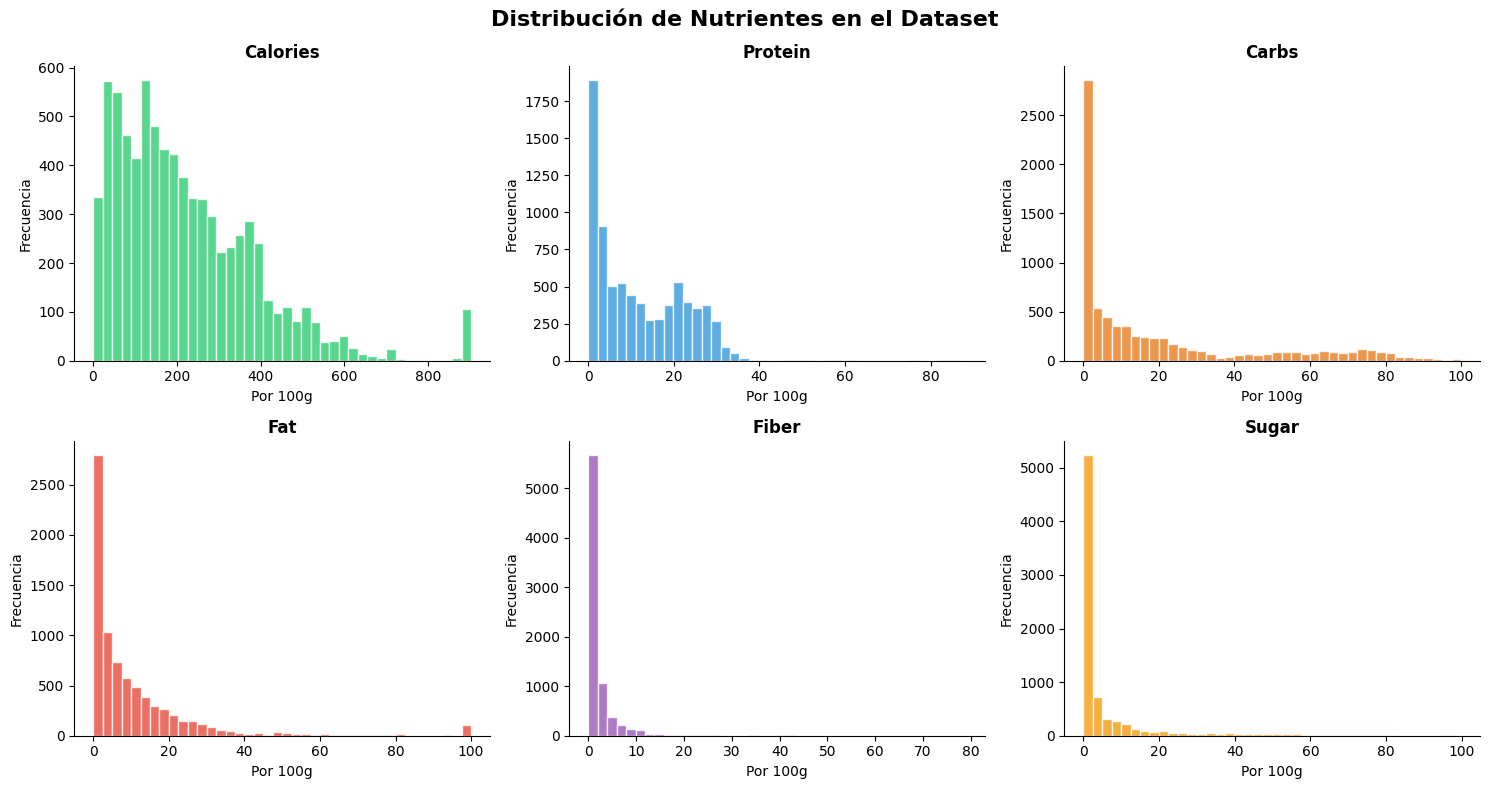

✅ Gráfica guardada


In [15]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Distribución de Nutrientes en el Dataset', fontsize=16, fontweight='bold')

cols_plot = ['calories', 'protein', 'carbs', 'fat', 'fiber', 'sugar']
colores = ['#2ecc71', '#3498db', '#e67e22', '#e74c3c', '#9b59b6', '#f39c12']

for ax, col, color in zip(axes.flatten(), cols_plot, colores):
    ax.hist(df[col], bins=40, color=color, alpha=0.8, edgecolor='white')
    ax.set_title(col.capitalize(), fontweight='bold')
    ax.set_xlabel('Por 100g')
    ax.set_ylabel('Frecuencia')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(PROCESSED + 'distribucion_nutrientes.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Gráfica guardada')

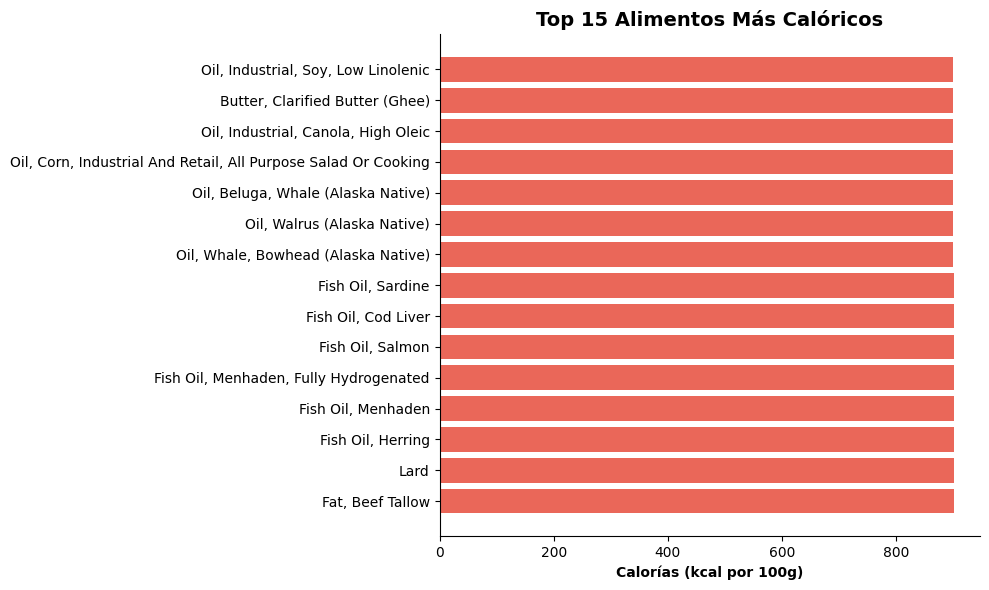

In [16]:
# Top 15 alimentos más calóricos
top_cal = df.nlargest(15, 'calories')[['nombre', 'calories', 'fat', 'protein']]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top_cal['nombre'], top_cal['calories'], color='#e74c3c', alpha=0.85)
ax.set_xlabel('Calorías (kcal por 100g)', fontweight='bold')
ax.set_title('Top 15 Alimentos Más Calóricos', fontsize=14, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(PROCESSED + 'top_caloricos.png', dpi=150, bbox_inches='tight')
plt.show()

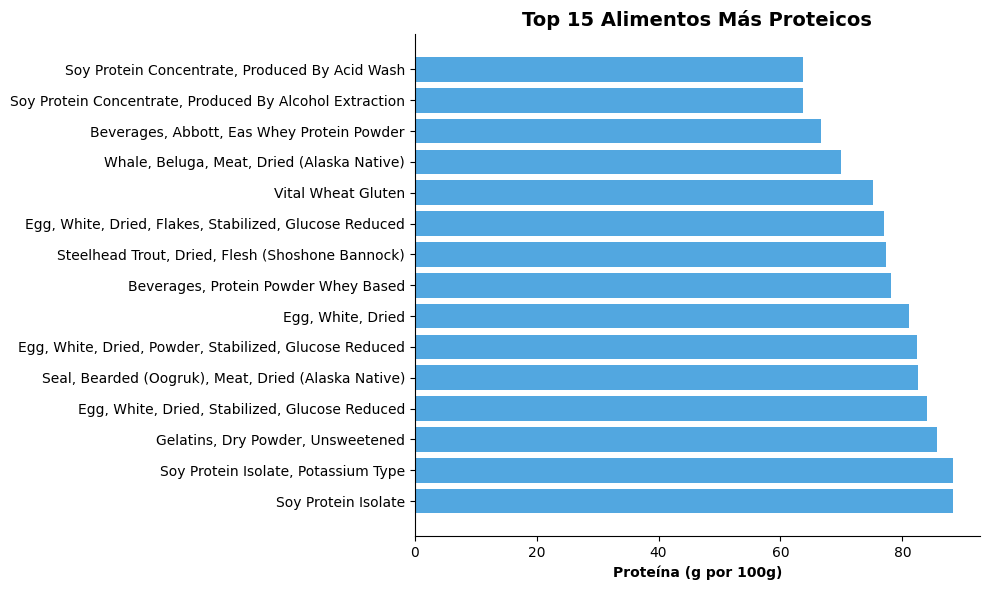

In [17]:
# Top 15 alimentos más proteicos
top_prot = df.nlargest(15, 'protein')[['nombre', 'protein', 'calories']]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_prot['nombre'], top_prot['protein'], color='#3498db', alpha=0.85)
ax.set_xlabel('Proteína (g por 100g)', fontweight='bold')
ax.set_title('Top 15 Alimentos Más Proteicos', fontsize=14, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(PROCESSED + 'top_proteicos.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Guardar dataset limpio

In [18]:
output_path = PROCESSED + 'foods_clean.csv'
df.to_csv(output_path, index=False)

print('✅ Dataset limpio guardado exitosamente')
print(f'📁 Ruta: {os.path.abspath(output_path)}')
print(f'📊 Alimentos: {len(df):,}')
print(f'📋 Columnas: {df.columns.tolist()}')
print()
print('Muestra final:')
df.sample(5)

✅ Dataset limpio guardado exitosamente
📁 Ruta: /Users/jorgelopez/Downloads/smart-diet-planner/data/processed/foods_clean.csv
📊 Alimentos: 7,756
📋 Columnas: ['fdc_id', 'nombre', 'calories', 'carbs', 'fat', 'fiber', 'protein', 'sugar']

Muestra final:


,fdc_id,nombre,calories,carbs,fat,fiber,protein,sugar
3344,170857,"Cream, Fluid, Light (Coffee Cream Or Table Cream)",195.0,3.66,19.10,0.0,2.96,3.67
7058,174596,Liverwurst Spread,305.0,5.89,25.45,2.5,12.38,1.65
3911,171424,"Oil, Tomatoseed",884.0,0.00,100.00,0.0,0.00,0.00
3373,170886,"Yogurt, Plain, Low Fat",63.0,7.04,1.55,0.0,5.25,7.04
3182,170695,"Fast Foods, Roast Beef Sandwich, Plain",244.0,22.21,10.30,1.3,15.17,3.84
